In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!ls -lh "/content/drive/MyDrive/Colab Notebooks/RDD2020/train.tar.gz"

-rw------- 1 root root 1.4G Aug 15 09:40 '/content/drive/MyDrive/Colab Notebooks/RDD2020/train.tar.gz'


In [4]:
!gzip -t "/content/drive/MyDrive/Colab Notebooks/RDD2020/train.tar.gz"

In [5]:
!mkdir -p /content/RDD2020

In [6]:
!tar -xzf "/content/drive/MyDrive/Colab Notebooks/RDD2020/train.tar.gz" -C /content/RDD2020

In [7]:
!find /content/RDD2020 -maxdepth 3 -type d

/content/RDD2020
/content/RDD2020/train
/content/RDD2020/train/Japan
/content/RDD2020/train/Japan/images
/content/RDD2020/train/Japan/annotations
/content/RDD2020/train/India
/content/RDD2020/train/India/images
/content/RDD2020/train/India/annotations
/content/RDD2020/train/Czech
/content/RDD2020/train/Czech/images
/content/RDD2020/train/Czech/annotations


In [8]:
!find /content/RDD2020 -type f | head -20

/content/RDD2020/train/label_map.pbtxt
/content/RDD2020/train/Japan/images/Japan_008628.jpg
/content/RDD2020/train/Japan/images/Japan_008170.jpg
/content/RDD2020/train/Japan/images/Japan_009147.jpg
/content/RDD2020/train/Japan/images/Japan_004484.jpg
/content/RDD2020/train/Japan/images/Japan_006829.jpg
/content/RDD2020/train/Japan/images/Japan_009144.jpg
/content/RDD2020/train/Japan/images/Japan_000207.jpg
/content/RDD2020/train/Japan/images/Japan_006487.jpg
/content/RDD2020/train/Japan/images/Japan_012894.jpg
/content/RDD2020/train/Japan/images/Japan_003587.jpg
/content/RDD2020/train/Japan/images/Japan_009045.jpg
/content/RDD2020/train/Japan/images/Japan_011522.jpg
/content/RDD2020/train/Japan/images/Japan_005487.jpg
/content/RDD2020/train/Japan/images/Japan_001659.jpg
/content/RDD2020/train/Japan/images/Japan_004028.jpg
/content/RDD2020/train/Japan/images/Japan_001862.jpg
/content/RDD2020/train/Japan/images/Japan_009675.jpg
/content/RDD2020/train/Japan/images/Japan_006954.jpg
/conten

In [9]:
from pathlib import Path

root = Path("/content/RDD2020")

images = list(root.rglob("*.jpg"))
xmls = list(root.rglob("*.xml"))

print("Images:", len(images))
print("XML annotations:", len(xmls))

Images: 21041
XML annotations: 21041


In [10]:
for country in ["India", "Japan", "Czech"]:
    imgs = list(root.glob(f"**/{country}/images/*.jpg"))
    anns = list(root.glob(f"**/{country}/annotations/*.xml"))

    print(country)
    print(" Images:", len(imgs))
    print(" XMLs:", len(anns))

India
 Images: 7706
 XMLs: 0
Japan
 Images: 10506
 XMLs: 0
Czech
 Images: 2829
 XMLs: 0


In [11]:
import xml.etree.ElementTree as ET

xml_file = xmls[0]

tree = ET.parse(xml_file)
root_xml = tree.getroot()

print(ET.tostring(root_xml, encoding="unicode")[:3000])

<annotation>
	<folder>images</folder>
	<filename>Japan_007236.jpg</filename>
	<size>
		<width>1080</width>
		<height>1080</height>
		<depth>3</depth>
	</size>
	<segmented>0</segmented>
	<object>
		<name>D20</name>
		<pose>Unspecified</pose>
		<truncated>1</truncated>
		<difficult>0</difficult>
		<bndbox>
			<xmin>836</xmin>
			<ymin>807</ymin>
			<xmax>1080</xmax>
			<ymax>976</ymax>
		</bndbox>
	</object>
	<object>
		<name>D10</name>
		<pose>Unspecified</pose>
		<truncated>0</truncated>
		<difficult>0</difficult>
		<bndbox>
			<xmin>680</xmin>
			<ymin>928</ymin>
			<xmax>813</xmax>
			<ymax>970</ymax>
		</bndbox>
	</object>
</annotation>


In [12]:
CLASS_MAP = {
    "D00": 0,  # Longitudinal crack
    "D10": 1,  # Transverse crack
    "D20": 2,  # Alligator crack
    "D40": 3   # Pothole
}

In [13]:
import os

base = "/content/road_damage"

folders = [
    "images/train",
    "images/val",
    "labels/train",
    "labels/val"
]

for folder in folders:
    os.makedirs(os.path.join(base, folder), exist_ok=True)

print("YOLO folders created.")

YOLO folders created.


In [14]:
import xml.etree.ElementTree as ET

CLASS_MAP = {
    "D00": 0,
    "D10": 1,
    "D20": 2,
    "D40": 3
}

def convert_xml_to_yolo(xml_path, image_width, image_height):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    yolo_annotations = []

    for obj in root.findall("object"):
        class_name = obj.find("name").text.strip()

        # Ignore classes outside our four target classes
        if class_name not in CLASS_MAP:
            continue

        bbox = obj.find("bndbox")

        xmin = float(bbox.find("xmin").text)
        ymin = float(bbox.find("ymin").text)
        xmax = float(bbox.find("xmax").text)
        ymax = float(bbox.find("ymax").text)

        # Convert VOC → YOLO
        x_center = ((xmin + xmax) / 2) / image_width
        y_center = ((ymin + ymax) / 2) / image_height

        width = (xmax - xmin) / image_width
        height = (ymax - ymin) / image_height

        class_id = CLASS_MAP[class_name]

        yolo_annotations.append(
            f"{class_id} {x_center:.6f} {y_center:.6f} "
            f"{width:.6f} {height:.6f}"
        )

    return yolo_annotations

In [15]:
from PIL import Image

xml_file = xmls[0]

tree = ET.parse(xml_file)
root_xml = tree.getroot()

filename = root_xml.find("filename").text

print("XML:", xml_file)
print("Image:", filename)

XML: /content/RDD2020/train/Japan/annotations/xmls/Japan_007236.xml
Image: Japan_007236.jpg


In [16]:
size = root_xml.find("size")

width = int(size.find("width").text)
height = int(size.find("height").text)

print("Width:", width)
print("Height:", height)

Width: 1080
Height: 1080


In [17]:
annotations = convert_xml_to_yolo(
    xml_file,
    width,
    height
)

print("\n".join(annotations))

2 0.887037 0.825463 0.225926 0.156481
1 0.691204 0.878704 0.123148 0.038889


In [18]:
import os

YOLO_ROOT = "/content/road_damage"

folders = [
    "images/train",
    "images/val",
    "labels/train",
    "labels/val"
]

for folder in folders:
    os.makedirs(os.path.join(YOLO_ROOT, folder), exist_ok=True)

print("YOLO dataset folders created successfully.")

YOLO dataset folders created successfully.


In [20]:
import xml.etree.ElementTree as ET

CLASS_MAP = {
    "D00": 0,  # Longitudinal crack
    "D10": 1,  # Transverse crack
    "D20": 2,  # Alligator crack
    "D40": 3   # Pothole
}

def convert_xml_to_yolo(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    size = root.find("size")

    image_width = int(size.find("width").text)
    image_height = int(size.find("height").text)

    annotations = []

    for obj in root.findall("object"):

        class_name = obj.find("name").text.strip()

        # Ignore unwanted classes
        if class_name not in CLASS_MAP:
            continue

        bbox = obj.find("bndbox")

        xmin = float(bbox.find("xmin").text)
        ymin = float(bbox.find("ymin").text)
        xmax = float(bbox.find("xmax").text)
        ymax = float(bbox.find("ymax").text)

        # Convert Pascal VOC → YOLO
        x_center = ((xmin + xmax) / 2) / image_width
        y_center = ((ymin + ymax) / 2) / image_height

        width = (xmax - xmin) / image_width
        height = (ymax - ymin) / image_height

        class_id = CLASS_MAP[class_name]

        annotations.append(
            f"{class_id} "
            f"{x_center:.6f} "
            f"{y_center:.6f} "
            f"{width:.6f} "
            f"{height:.6f}"
        )

    return annotations

print("XML → YOLO converter ready.")

XML → YOLO converter ready.


In [25]:
from pathlib import Path

RDD_ROOT = Path("/content/RDD2020/train")

pairs = []

for country_dir in RDD_ROOT.iterdir():

    if not country_dir.is_dir():
        continue

    image_dir = country_dir / "images"
    xml_dir = country_dir / "annotations" / "xmls"

    if not image_dir.exists() or not xml_dir.exists():
        print(f"Skipping {country_dir.name}")
        continue

    for xml_file in xml_dir.glob("*.xml"):

        image_file = image_dir / f"{xml_file.stem}.jpg"

        if image_file.exists():
            pairs.append((image_file, xml_file))

print("Valid image/XML pairs:", len(pairs))

Valid image/XML pairs: 21041


In [26]:
import random

random.seed(42)

random.shuffle(pairs)

split_index = int(len(pairs) * 0.8)

train_pairs = pairs[:split_index]
val_pairs = pairs[split_index:]

print("Training images:", len(train_pairs))
print("Validation images:", len(val_pairs))

Training images: 16832
Validation images: 4209


In [27]:
import shutil

def process_dataset(pairs, split):

    image_output = Path(YOLO_ROOT) / "images" / split
    label_output = Path(YOLO_ROOT) / "labels" / split

    processed = 0
    skipped = 0

    for image_file, xml_file in pairs:

        annotations = convert_xml_to_yolo(xml_file)

        # Skip images where none of our 4 classes exist
        if len(annotations) == 0:
            skipped += 1
            continue

        # Give every image a unique name
        new_name = f"{image_file.parent.parent.name}_{image_file.name}"

        destination_image = image_output / new_name
        destination_label = label_output / f"{Path(new_name).stem}.txt"

        # Copy image
        shutil.copy2(image_file, destination_image)

        # Write YOLO label
        with open(destination_label, "w") as f:
            f.write("\n".join(annotations))

        processed += 1

    return processed, skipped

In [28]:
train_processed, train_skipped = process_dataset(
    train_pairs,
    "train"
)

print("Training processed:", train_processed)
print("Training skipped:", train_skipped)

Training processed: 9767
Training skipped: 7065


In [29]:
val_processed, val_skipped = process_dataset(
    val_pairs,
    "val"
)

print("Validation processed:", val_processed)
print("Validation skipped:", val_skipped)

Validation processed: 2428
Validation skipped: 1781


In [30]:
print(
    "Train images:",
    len(list(Path(YOLO_ROOT, "images/train").glob("*.jpg")))
)

print(
    "Train labels:",
    len(list(Path(YOLO_ROOT, "labels/train").glob("*.txt")))
)

print(
    "Val images:",
    len(list(Path(YOLO_ROOT, "images/val").glob("*.jpg")))
)

print(
    "Val labels:",
    len(list(Path(YOLO_ROOT, "labels/val").glob("*.txt")))
)

Train images: 9767
Train labels: 9767
Val images: 2428
Val labels: 2428


In [31]:
label_files = list(
    Path(YOLO_ROOT, "labels/train").glob("*.txt")
)

print("Example label:")
print(label_files[0].read_text())

Example label:
0 0.684167 0.825833 0.065000 0.091667


In [32]:
yaml_content = """
path: /content/road_damage

train: images/train
val: images/val

names:
  0: longitudinal_crack
  1: transverse_crack
  2: alligator_crack
  3: pothole
"""

with open("/content/road_damage/data.yaml", "w") as f:
    f.write(yaml_content.strip())

print(yaml_content)


path: /content/road_damage

train: images/train
val: images/val

names:
  0: longitudinal_crack
  1: transverse_crack
  2: alligator_crack
  3: pothole



In [33]:
!cat /content/road_damage/data.yaml

path: /content/road_damage

train: images/train
val: images/val

names:
  0: longitudinal_crack
  1: transverse_crack
  2: alligator_crack
  3: pothole

In [34]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 5.5 MB/s eta 0:00:00


In [35]:
from ultralytics import YOLO

print("Ultralytics imported successfully!")

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics imported successfully!


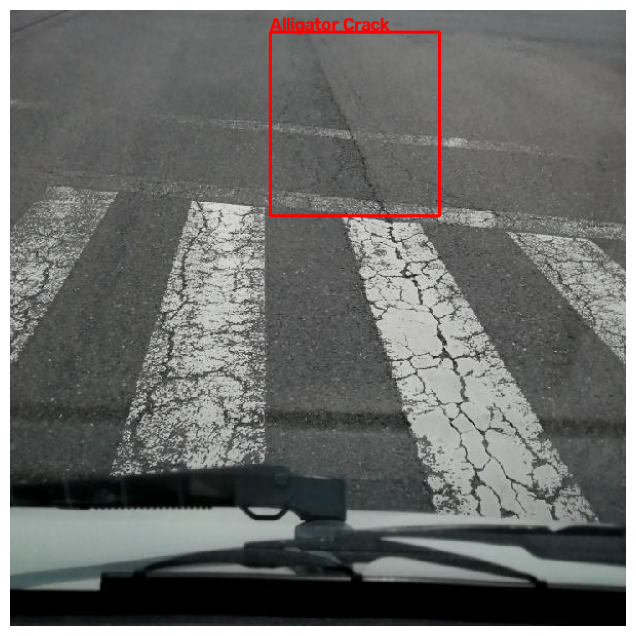

In [36]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

image_files = list(
    Path(YOLO_ROOT, "images/train").glob("*.jpg")
)

label_files = list(
    Path(YOLO_ROOT, "labels/train").glob("*.txt")
)

image_path = image_files[0]
label_path = Path(YOLO_ROOT, "labels/train") / f"{image_path.stem}.txt"

image = cv2.imread(str(image_path))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

h, w, _ = image.shape

with open(label_path) as f:

    for line in f:

        values = line.strip().split()

        class_id = int(values[0])

        x_center = float(values[1]) * w
        y_center = float(values[2]) * h

        box_width = float(values[3]) * w
        box_height = float(values[4]) * h

        xmin = int(x_center - box_width / 2)
        ymin = int(y_center - box_height / 2)
        xmax = int(x_center + box_width / 2)
        ymax = int(y_center + box_height / 2)

        cv2.rectangle(
            image,
            (xmin, ymin),
            (xmax, ymax),
            (255, 0, 0),
            2
        )

        class_names = [
            "Longitudinal Crack",
            "Transverse Crack",
            "Alligator Crack",
            "Pothole"
        ]

        cv2.putText(
            image,
            class_names[class_id],
            (xmin, max(ymin - 5, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 0, 0),
            2
        )

plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.axis("off")
plt.show()